In [11]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
train = pd.read_csv("../dataset/train_fe.csv")
test = pd.read_csv("../dataset/test_fe.csv")

print(train.shape)
print(test.shape)

train.head()

(77299, 30)
(41778, 29)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,geo5_freq,geo6_freq,lat,lon,geo4_mean_demand,geo5_mean_demand,geo6_mean_demand,geo4_hour_mean,geo5_hour_mean,geo6_hour_mean
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,...,1389,33,-5.484924,90.664673,0.142910,0.146484,0.035970,0.065837,0.065837,0.032530
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,...,1389,89,-5.462952,90.686646,0.138964,0.142242,0.200072,0.066115,0.066115,0.145019
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,...,842,67,-5.462952,90.708618,0.056502,0.075456,0.126477,0.023239,0.033678,0.059017
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,...,614,42,-5.462952,90.862427,0.056808,0.033490,0.014768,0.025642,0.015965,0.020986
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,...,1389,36,-5.457458,90.675659,0.142910,0.146484,0.030562,0.065837,0.065837,0.025710


In [40]:
day48 = train[
    train["day"] == 48
].copy()

day49 = train[
    train["day"] == 49
].copy()

print(day48.shape)
print(day49.shape)

(69427, 30)
(7872, 30)


In [41]:
TARGET = "demand"

DROP_COLS = [
    "Index",
    "timestamp",
    TARGET
]

FEATURES = [
    c
    for c in train.columns
    if c not in DROP_COLS
]

print(len(FEATURES))

27


In [38]:
from sklearn.model_selection import train_test_split

In [42]:
day48_train, day48_valid = train_test_split(
    day48,
    test_size=0.10,
    random_state=42
)

In [43]:
day49_train, day49_valid = train_test_split(
    day49,
    test_size=0.50,
    random_state=42
)

In [44]:
train_df = pd.concat(
    [
        day48_train,
        day49_train
    ],
    ignore_index=True
)

valid_df = pd.concat(
    [
        day48_valid,
        day49_valid
    ],
    ignore_index=True
)

In [45]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_valid = valid_df[FEATURES]
y_valid = valid_df[TARGET]

In [46]:
CAT_FEATURES = [
    "geohash",
    "geo4",
    "geo5",
    "geo6",
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks"
]

In [47]:
for col in CAT_FEATURES:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)

In [48]:
for col in CAT_FEATURES:

    X_train[col] = (
        X_train[col]
        .fillna("MISSING")
        .astype(str)
    )

    X_valid[col] = (
        X_valid[col]
        .fillna("MISSING")
        .astype(str)
    )

In [49]:
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,

    loss_function="RMSE",
    eval_metric="RMSE",

    random_seed=42,

    od_type="Iter",
    od_wait=200,

    verbose=200
)

In [50]:
model.fit(
    X_train,
    y_train,

    cat_features=CAT_FEATURES,

    eval_set=(
        X_valid,
        y_valid
    ),

    use_best_model=True
)

0:	learn: 0.1377901	test: 0.1420030	best: 0.1420030 (0)	total: 50ms	remaining: 2m 30s
200:	learn: 0.0284240	test: 0.0326039	best: 0.0326039 (200)	total: 15s	remaining: 3m 28s
400:	learn: 0.0269938	test: 0.0316447	best: 0.0316447 (400)	total: 30.5s	remaining: 3m 17s
600:	learn: 0.0261953	test: 0.0313935	best: 0.0313906 (591)	total: 45.4s	remaining: 3m 1s
800:	learn: 0.0255979	test: 0.0312967	best: 0.0312896 (756)	total: 59.5s	remaining: 2m 43s
1000:	learn: 0.0249874	test: 0.0311985	best: 0.0311985 (1000)	total: 1m 14s	remaining: 2m 28s
1200:	learn: 0.0244387	test: 0.0311166	best: 0.0311166 (1200)	total: 1m 29s	remaining: 2m 14s
1400:	learn: 0.0239690	test: 0.0310613	best: 0.0310561 (1365)	total: 1m 45s	remaining: 2m
1600:	learn: 0.0235295	test: 0.0309979	best: 0.0309969 (1599)	total: 2m 1s	remaining: 1m 45s
1800:	learn: 0.0231167	test: 0.0309616	best: 0.0309606 (1791)	total: 2m 16s	remaining: 1m 31s
2000:	learn: 0.0227490	test: 0.0309285	best: 0.0309285 (2000)	total: 2m 32s	remaining: 1

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=3000, learning_rate=0.03, loss_function='RMSE', od_type='Iter', od_wait=200, random_seed=42, verbose=200)

In [51]:
valid_pred = model.predict(
    X_valid
)

In [52]:
rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

r2 = r2_score(
    y_valid,
    valid_pred
)

score = max(
    0,
    100 * r2
)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("Score:", score)

RMSE : 0.030923481415893007
MAE  : 0.019768499753463425
R2   : 0.9549497117745378
Score: 95.49497117745378


In [53]:
fi = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
})

fi = fi.sort_values(
    "importance",
    ascending=False
)

fi.head(30)

,feature,importance
26,geo6_hour_mean,51.852398
2,RoadType,18.731237
4,LargeVehicles,5.193206
23,geo6_mean_demand,5.056496
3,NumberofLanes,4.364761
1,day,2.514591
10,minute_of_day,2.153791
18,geo6_freq,1.002338
9,minute,0.970162
11,hour_sin,0.954036


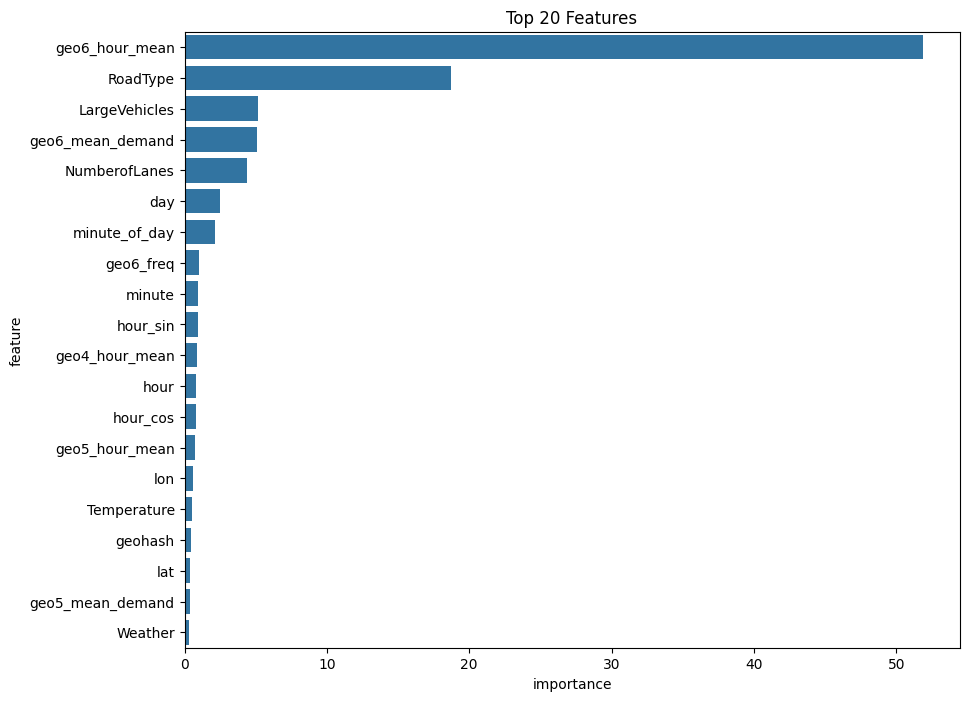

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=fi.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Features"
)

plt.show()

In [55]:
X_full = train[FEATURES]
y_full = train[TARGET]

for col in CAT_FEATURES:
    X_full[col] = X_full[col].astype(str)

X_test = test[FEATURES]

for col in CAT_FEATURES:
    X_test[col] = X_test[col].astype(str)

for col in CAT_FEATURES:

    X_full[col] = (
        X_full[col]
        .fillna("MISSING")
        .astype(str)
    )

    X_test[col] = (
        X_test[col]
        .fillna("MISSING")
        .astype(str)
    )



In [56]:
final_model = CatBoostRegressor(
    iterations=model.best_iteration_,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

final_model.fit(
    X_full,
    y_full,
    cat_features=CAT_FEATURES
)

0:	learn: 0.1383991	total: 80.6ms	remaining: 2m 43s
200:	learn: 0.0290436	total: 16.6s	remaining: 2m 31s
400:	learn: 0.0276025	total: 33.8s	remaining: 2m 16s
600:	learn: 0.0266795	total: 51.5s	remaining: 2m 2s
800:	learn: 0.0259593	total: 1m 10s	remaining: 1m 47s
1000:	learn: 0.0253708	total: 1m 28s	remaining: 1m 30s
1200:	learn: 0.0248913	total: 1m 45s	remaining: 1m 12s
1400:	learn: 0.0244805	total: 2m 3s	remaining: 55.2s
1600:	learn: 0.0240696	total: 2m 20s	remaining: 37.4s
1800:	learn: 0.0237390	total: 2m 37s	remaining: 19.8s
2000:	learn: 0.0233846	total: 2m 56s	remaining: 2.29s
2026:	learn: 0.0233369	total: 2m 58s	remaining: 0us


CatBoostRegressor(depth=8, iterations=2027, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [57]:
test_pred = final_model.predict(
    X_test
)

In [58]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_pred
})

submission.head()

,Index,demand
0,0,0.064649
1,1,0.020085
2,2,0.009573
3,3,0.047842
4,4,0.054587


In [59]:
import os

os.makedirs(
    "../outputs",
    exist_ok=True
)

submission.to_csv(
    "../outputs/CATBOOST_V2_ANS.csv",
    index=False
)

print(
    "Saved!"
)

Saved!
